# Which separation change should SOE model?

The current outcome chooses the nearest coverage defender independently at snap and release. This notebook compares it with two alternatives: following the snap-nearest defender, and measuring the nearest defender among the snap's three closest coverage defenders at both endpoints. All targets use a common complete-case WR route set, identical five-fold game-held-out assignments, and identical model settings. The model inputs exclude all realized route geometry and all target-definition fields.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from separation_over_expected.features import build_route_table
from separation_over_expected.reports import read_csv_rows
from separation_over_expected.target_comparison import compare_separation_targets

OUTPUT_DIR = PROJECT_ROOT / "data/processed/separation_target_audit"
ROUTE_TABLE = OUTPUT_DIR / "route_table.csv"
if not ROUTE_TABLE.exists():
    build_route_table(
        PROJECT_ROOT.parent / "data/big_data_bowl_2023", ROUTE_TABLE,
        list(range(1, 9)), include_pocket_features=True,
    )
if not (OUTPUT_DIR / "reliability_summary.csv").exists():
    RESULTS = compare_separation_targets(read_csv_rows(ROUTE_TABLE), OUTPUT_DIR)
else:
    RESULTS = {name: read_csv_rows(OUTPUT_DIR / f"{name}.csv") for name in (
        "target_distributions", "switch_rates", "target_correlations", "model_metrics",
        "fold_metrics", "calibration_deciles", "reliability_seeds",
        "reliability_summary", "route_diagnostics", "oof_predictions",
    )}
print("Target-comparison outputs loaded. See route counts and excluded rows below.")

Target-comparison outputs loaded. See route counts and excluded rows below.


## Sample and target behavior

Complete-case selection requires the snap-nearest defender and all three snap-nearest defenders to be present at release. This makes target comparisons paired on the same routes; the excluded count is reported explicitly. The three outcome distributions are not interchangeable, so compare their scales and correlations before comparing model errors.

In [1]:
from IPython.display import HTML, SVG, display

LABELS = {
    "endpoint_nearest": "Nearest at each endpoint",
    "snap_anchor": "Follow snap-nearest defender",
    "snap_top3": "Nearest of snap top three",
}
MODEL_LABELS = {
    "ridge_dynamic_context": "Dynamic Ridge",
    "extra_trees": "Extra Trees",
    "hist_gradient_boosting": "Hist. gradient boosting",
}
COLORS = {"endpoint_nearest":"#1976a5", "snap_anchor":"#8466a8", "snap_top3":"#e08a28"}

def html_table(headers, rows):
    head = "".join(f"<th>{header}</th>" for header in headers)
    body = "".join("<tr>" + "".join(f"<td>{value}</td>" for value in row) + "</tr>" for row in rows)
    return f"<table><thead><tr>{head}</tr></thead><tbody>{body}</tbody></table>"

switch = RESULTS["switch_rates"][0]
display(HTML(html_table(
    ["Common WR routes", "Routes excluded", "Nearest-defender switches", "Switch rate"],
    [[switch["routes"], switch["excluded_missing_target_routes"], switch["defender_switches"], f"{float(switch['switch_rate']):.1%}"]],
)))
display(HTML(html_table(
    ["Target", "Mean", "SD", "Median", "5th–95th pct.", "Positive share"],
    [[LABELS[r["target"]], f"{float(r['mean']):.3f}", f"{float(r['sd']):.3f}", f"{float(r['median']):.3f}", f"{float(r['p05']):.2f}–{float(r['p95']):.2f}", f"{float(r['positive_fraction']):.1%}"] for r in RESULTS["target_distributions"]],
)))
display(HTML(html_table(
    ["Target A", "Target B", "Pearson", "Spearman"],
    [[LABELS[r["target_a"]], LABELS[r["target_b"]], f"{float(r['pearson']):.3f}", f"{float(r['spearman']):.3f}"] for r in RESULTS["target_correlations"]],
)))

Common WR routes,Routes excluded,Nearest-defender switches,Switch rate
20415,0,7795,38.2%


Target,Mean,SD,Median,5th–95th pct.,Positive share
Nearest at each endpoint,-2.341,2.664,-2.132,-6.65–1.85,14.7%
Follow snap-nearest defender,0.479,5.987,-1.047,-6.10–12.55,36.8%
Nearest of snap top three,-1.900,3.459,-1.963,-6.60–3.74,18.5%


Target A,Target B,Pearson,Spearman
Nearest at each endpoint,Follow snap-nearest defender,0.443,0.593
Nearest at each endpoint,Nearest of snap top three,0.808,0.931
Follow snap-nearest defender,Nearest of snap top three,0.630,0.668


## Route prediction and calibration

Each target is evaluated with the same fixed Dynamic Ridge, Extra Trees, and histogram-gradient-boosting specifications. RMSE is reported in yards and normalized by that target's standard deviation; absolute RMSE across targets should not be compared without considering the different outcome scales. Route-level fit is descriptive evidence, not the selection criterion by itself.

In [1]:
def metric_table(rows):
    return html_table(
        ["Target", "Model", "RMSE", "Normalized RMSE", "MAE", "R²", "Calibration slope", "Mean decile bias"],
        [[LABELS[r["target"]], MODEL_LABELS[r["model"]], r["rmse"], r["normalized_rmse"], r["mae"], r["r2"], f"{float(r['calibration_slope']):.3f}", f"{float(r['mean_absolute_decile_bias']):.3f}"] for r in RESULTS["model_metrics"]],
    )

display(HTML(metric_table(RESULTS["model_metrics"])))

Target,Model,RMSE,Normalized RMSE,MAE,R²,Calibration slope,Mean decile bias
Nearest at each endpoint,Dynamic Ridge,1.869,0.701471,1.363,0.508,0.997,0.051
Nearest at each endpoint,Extra Trees,1.827,0.685708,1.312,0.530,1.030,0.068
Nearest at each endpoint,Hist. gradient boosting,1.794,0.673322,1.284,0.547,1.013,0.037
Follow snap-nearest defender,Dynamic Ridge,4.590,0.766661,3.211,0.412,0.991,0.516
Follow snap-nearest defender,Extra Trees,4.279,0.714715,2.866,0.489,1.184,0.473
Follow snap-nearest defender,Hist. gradient boosting,4.067,0.679305,2.713,0.539,1.028,0.114
Nearest of snap top three,Dynamic Ridge,2.678,0.774297,1.771,0.401,0.993,0.161
Nearest of snap top three,Extra Trees,2.584,0.747118,1.661,0.442,1.073,0.102
Nearest of snap top three,Hist. gradient boosting,2.538,0.733818,1.631,0.462,1.002,0.031


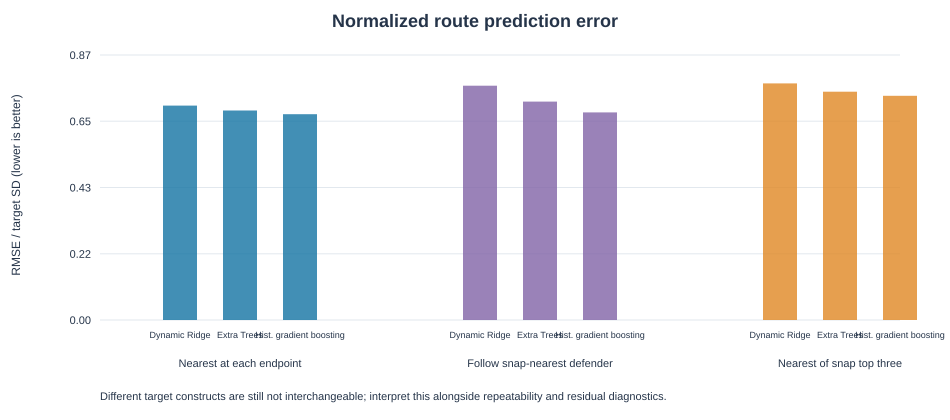

In [1]:
def normalized_error_plot(rows, width=950, height=420):
    left,right,top,bottom=100,900,55,320
    ymax=max(float(row["normalized_rmse"]) for row in rows)*1.12
    y=lambda value: bottom-float(value)/ymax*(bottom-top)
    parts=[f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}"><rect width="100%" height="100%" fill="white"/><style>text{{font-family:Arial,sans-serif;fill:#253449}}.grid{{stroke:#e2e8ee}}</style><text x="475" y="27" text-anchor="middle" font-size="18" font-weight="bold">Normalized route prediction error</text>']
    for i in range(5):
        value=ymax*i/4; yy=y(value)
        parts += [f'<line class="grid" x1="{left}" y1="{yy:.1f}" x2="{right}" y2="{yy:.1f}"/>',f'<text x="{left-9}" y="{yy+4:.1f}" text-anchor="end" font-size="11">{value:.2f}</text>']
    target_centers={name:240+i*300 for i,name in enumerate(LABELS)}
    model_offsets={"ridge_dynamic_context":-60,"extra_trees":0,"hist_gradient_boosting":60}
    for row in rows:
        x=target_centers[row["target"]]+model_offsets[row["model"]]; yy=y(row["normalized_rmse"]); color=COLORS[row["target"]]
        parts += [f'<rect x="{x-17}" y="{yy:.1f}" width="34" height="{bottom-yy:.1f}" fill="{color}" opacity=".82"/>',f'<text x="{x}" y="{bottom+18}" text-anchor="middle" font-size="9">{MODEL_LABELS[row["model"]]}</text>']
    for name,x in target_centers.items(): parts.append(f'<text x="{x}" y="{bottom+47}" text-anchor="middle" font-size="11">{LABELS[name]}</text>')
    parts += ['<text x="20" y="185" text-anchor="middle" font-size="12" transform="rotate(-90 20 185)">RMSE / target SD (lower is better)</text>','<text x="100" y="400" font-size="11">Different target constructs are still not interchangeable; interpret this alongside repeatability and residual diagnostics.</text>','</svg>']
    return ''.join(parts)

display(SVG(normalized_error_plot(RESULTS["model_metrics"])))

## Receiver repeatability

Pearson and Spearman correlations compare each receiver's average out-of-fold residual across disjoint game halves. Points are medians across 100 balanced assignments; whiskers cover the 10th–90th percentile of assignment results, not a confidence interval. The table also exposes sensitivity to the minimum routes required in each half.

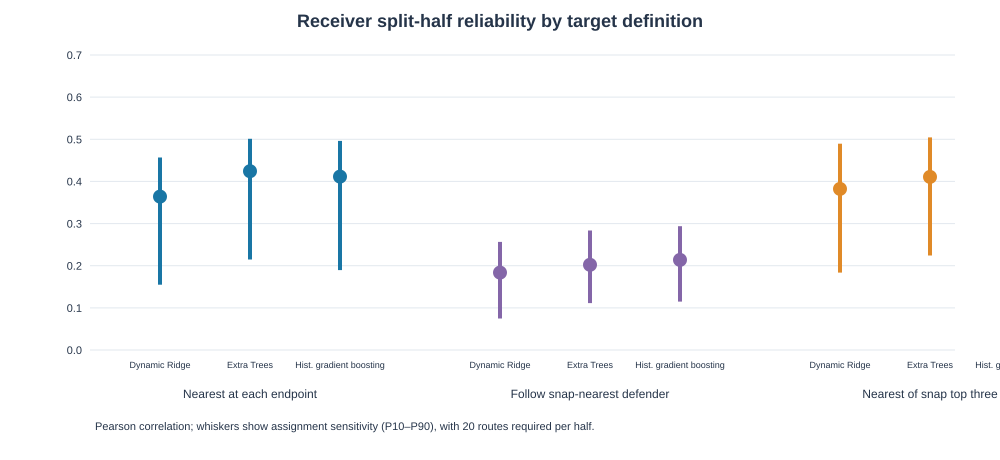

Target,Model,Min routes/half,Median Pearson,P10–P90,Median eligible receivers
Nearest at each endpoint,Dynamic Ridge,10,0.257,0.146–0.346,136
Nearest at each endpoint,Dynamic Ridge,20,0.364,0.155–0.457,112
Nearest at each endpoint,Dynamic Ridge,30,0.419,0.136–0.532,89
Nearest at each endpoint,Dynamic Ridge,40,0.300,0.161–0.583,74
Nearest at each endpoint,Dynamic Ridge,50,0.296,0.169–0.399,57
Nearest at each endpoint,Extra Trees,10,0.294,0.191–0.400,136
Nearest at each endpoint,Extra Trees,20,0.424,0.215–0.501,112
Nearest at each endpoint,Extra Trees,30,0.470,0.186–0.579,89
Nearest at each endpoint,Extra Trees,40,0.342,0.192–0.631,74
Nearest at each endpoint,Extra Trees,50,0.317,0.194–0.420,57


In [1]:
def reliability_plot(rows, width=1000, height=460):
    selected = [r for r in rows if r["metric"] == "pearson" and r["min_routes_per_half"] == "20"]
    left, right, top, bottom = 90, 955, 55, 350
    y = lambda v: bottom - float(v) / .7 * (bottom-top)
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}"><rect width="100%" height="100%" fill="white"/><style>text{{font-family:Arial,sans-serif;fill:#253449}}.grid{{stroke:#e2e8ee}}</style><text x="500" y="27" text-anchor="middle" font-size="18" font-weight="bold">Receiver split-half reliability by target definition</text>']
    for tick in (0,.1,.2,.3,.4,.5,.6,.7):
        yy=y(tick);parts += [f'<line class="grid" x1="{left}" y1="{yy:.1f}" x2="{right}" y2="{yy:.1f}"/>',f'<text x="{left-8}" y="{yy+4:.1f}" text-anchor="end" font-size="11">{tick:.1f}</text>']
    target_x={name:250+i*340 for i,name in enumerate(LABELS)}
    model_dx={"ridge_dynamic_context":-90,"extra_trees":0,"hist_gradient_boosting":90}
    for row in selected:
        x=target_x[row["target"]]+model_dx[row["model"]];color=COLORS[row["target"]]
        parts += [f'<line x1="{x}" y1="{y(row["p10"]):.1f}" x2="{x}" y2="{y(row["p90"]):.1f}" stroke="{color}" stroke-width="4"/>',f'<circle cx="{x}" cy="{y(row["median"]):.1f}" r="7" fill="{color}"/>',f'<text x="{x}" y="{bottom+18}" text-anchor="middle" font-size="9">{MODEL_LABELS[row["model"]]}</text>']
    for name,x in target_x.items():parts.append(f'<text x="{x}" y="{bottom+48}" text-anchor="middle" font-size="12">{LABELS[name]}</text>')
    parts += ['<text x="95" y="430" font-size="11">Pearson correlation; whiskers show assignment sensitivity (P10–P90), with 20 routes required per half.</text>','</svg>']
    return "".join(parts)

display(SVG(reliability_plot(RESULTS["reliability_summary"])))

def threshold_rows(rows):
    selected = [r for r in rows if r["metric"] == "pearson"]
    table_rows = []
    for r in selected:
        receiver_count = next(item["median"] for item in rows if item["target"] == r["target"] and item["model"] == r["model"] and item["min_routes_per_half"] == r["min_routes_per_half"] and item["metric"] == "receivers")
        table_rows.append([LABELS[r["target"]], MODEL_LABELS[r["model"]], r["min_routes_per_half"], f"{float(r['median']):.3f}", f"{float(r['p10']):.3f}–{float(r['p90']):.3f}", f"{float(receiver_count):.0f}"])
    return html_table(["Target", "Model", "Min routes/half", "Median Pearson", "P10–P90", "Median eligible receivers"], table_rows)

display(HTML(threshold_rows(RESULTS["reliability_summary"])))

## Does the target behave differently on switches and shallow routes?

Residual is observed target minus expected target. Positive values mean the model underpredicted the outcome. Look for target definitions that reduce the switch-associated and shallow-route patterns while retaining receiver repeatability. Small alignment groups should be interpreted cautiously.

In [1]:
def diagnostic_table(rows, group_type):
    chosen = [r for r in rows if r["group_type"] == group_type]
    return html_table(
        ["Target", "Model", "Group", "Routes", "Mean residual", "RMSE"],
        [[LABELS[r["target"]], MODEL_LABELS[r["model"]], r["group"], r["routes"], f"{float(r['mean_residual']):+.3f}", r["rmse"]] for r in chosen],
    )

display(HTML(diagnostic_table(RESULTS["route_diagnostics"], "defender_switch")))
display(HTML(diagnostic_table(RESULTS["route_diagnostics"], "route_depth")))

Target,Model,Group,Routes,Mean residual,RMSE
Nearest at each endpoint,Dynamic Ridge,switched,7795,+0.289,2.219334
Nearest at each endpoint,Dynamic Ridge,stable,12620,-0.177,1.614906
Nearest at each endpoint,Extra Trees,switched,7795,+0.264,2.198508
Nearest at each endpoint,Extra Trees,stable,12620,-0.164,1.553670
Nearest at each endpoint,Hist. gradient boosting,switched,7795,+0.242,2.179302
Nearest at each endpoint,Hist. gradient boosting,stable,12620,-0.149,1.507499
Follow snap-nearest defender,Dynamic Ridge,switched,7795,+2.899,5.987567
Follow snap-nearest defender,Dynamic Ridge,stable,12620,-1.786,3.455017
Follow snap-nearest defender,Extra Trees,switched,7795,+2.831,5.842872
Follow snap-nearest defender,Extra Trees,stable,12620,-1.725,2.920358


Target,Model,Group,Routes,Mean residual,RMSE
Nearest at each endpoint,Dynamic Ridge,10+ yd,9533,-0.219,1.750457
Nearest at each endpoint,Dynamic Ridge,5–10 yd,7580,-0.099,1.613878
Nearest at each endpoint,Dynamic Ridge,2–5 yd,2778,+0.426,1.938441
Nearest at each endpoint,Dynamic Ridge,<2 yd,524,+3.187,4.768377
Nearest at each endpoint,Extra Trees,10+ yd,9533,-0.220,1.721765
Nearest at each endpoint,Extra Trees,5–10 yd,7580,-0.124,1.569144
Nearest at each endpoint,Extra Trees,2–5 yd,2778,+0.457,1.812587
Nearest at each endpoint,Extra Trees,<2 yd,524,+3.334,4.803185
Nearest at each endpoint,Hist. gradient boosting,10+ yd,9533,-0.198,1.706034
Nearest at each endpoint,Hist. gradient boosting,5–10 yd,7580,-0.108,1.549154


## Decision

The endpoint-nearest outcome remains the best current reference: it has the lowest normalized RMSE for all three models. Receiver repeatability is mixed between endpoint-nearest and snap-top-three: snap-top-three is modestly higher for Ridge, while endpoint-nearest is higher for both tree models. Snap-top-three is highly rank-correlated with endpoint-nearest, but does not consistently improve receiver reliability or the shallow-route residual. Following one snap defender substantially increases target variance and produces much weaker receiver repeatability, especially when defenders switch. None of the alternatives removes the shallow-route bias. Keep the endpoint-nearest definition for now, document defender switching as a limitation, and investigate whether the switch/shallow residuals reflect route assignment, coverage handoffs, or an unsuitable separation proxy before claiming a stable player skill score.

The 2023 transfer check should follow this measurement decision. Its pre-throw window is snap-to-release-like but not event-anchored identically.

In [1]:
display(HTML(diagnostic_table(RESULTS["route_diagnostics"], "alignment")))

Target,Model,Group,Routes,Mean residual,RMSE
Nearest at each endpoint,Dynamic Ridge,LWR,6213,-0.001,1.802279
Nearest at each endpoint,Dynamic Ridge,SRWR,1938,-0.003,2.045047
Nearest at each endpoint,Dynamic Ridge,SLWR,2349,-0.006,2.057402
Nearest at each endpoint,Dynamic Ridge,RWR,6097,-0.001,1.746541
Nearest at each endpoint,Dynamic Ridge,SRoWR,1306,-0.011,1.759172
Nearest at each endpoint,Dynamic Ridge,SRiWR,714,-0.017,2.235892
Nearest at each endpoint,Dynamic Ridge,SLiWR,648,-0.031,2.067908
Nearest at each endpoint,Dynamic Ridge,SLoWR,1028,-0.006,1.629468
Nearest at each endpoint,Dynamic Ridge,TE-oR,6,-0.138,1.363603
Nearest at each endpoint,Dynamic Ridge,HB-R,18,+0.725,3.127635
